
<br/>
<b>Última actualización</b>:12 de septiembre
<hr/>

Escribe un programa que demuestre , en la practica , el funcionamiento del teorema del limite central(TLC). El programa debe de mostrar el funcionamiento del teorema del límite central en la medida en que el limite $n \to \infty $ se satisface para diferentes distribuciones de probabilidad para las muestras involucradas.  

In [ ]:
!pip install -q tqdm

In [ ]:
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
N=100000

In [ ]:
#Tamaño de la muestra
n=np.arange(0,N,10)


In [ ]:
n.shape

(10000,)

In [ ]:
##################DISTRIBUCIÓN A ESTUDIAR#####################################
# Parámetro de la distribución de Poisson (tasa de eventos)
lmbda = 3.0

# Generar 100 muestras aleatorias de la distribución de Poisson
poblacion = stats.poisson.rvs(lmbda, size=N)



In [ ]:
poblacion

array([3, 2, 3, ..., 5, 3, 3])

In [ ]:
poblacion.shape

(100000,)

INDEPENDENCIA DE VARIABLES....

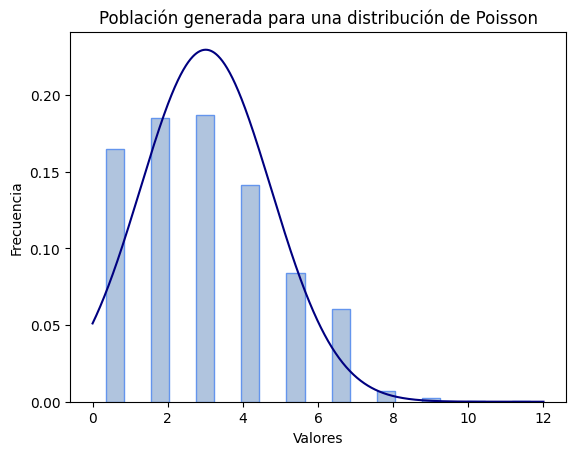

In [ ]:



import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm



# Generar datos de ejemplo
datos = np.random.randn(100)  # Datos aleatorios

# Crear una figura y ejes personalizados
fig, ax = plt.subplots()

# Graficar el histograma con Matplotlib en el eje personalizado
n_, bins, patches = ax.hist(poblacion, edgecolor='cornflowerblue',color="lightsteelblue", rwidth=0.4, density=True)  # Especifica el número de bins
ax.set_xlabel('Valores')
ax.set_ylabel('Frecuencia')
ax.set_title('Población generada para una distribución de Poisson')

# Ajustar una distribución normal a los datos
mu, std = norm.fit(poblacion)

x = np.linspace(min(bins), max(bins), 1000)

# Calcular la función de densidad de probabilidad de la distribución normal en la resolución aumentada
pdf = norm.pdf(x, mu, std)

# Graficar la curva de ajuste
ax.plot(x, pdf, color='navy', label='Distribución Normal')

# Mostrar la trama

plt.savefig('pobl.png')


##**MUESTRAS DE MEDIAS**

In [ ]:
n

array([    0,    10,    20, ..., 99970, 99980, 99990])

In [ ]:
# Extraer una muestra de tamaño n de la población
def mu(num,pob):
  muestra=np.zeros(len(num)-1)
  desv_est=np.zeros(len(num)-1)
  mediana=np.zeros(len(num)-1)
  for i in tqdm(range(len(muestra)), desc="Calculando medias"):
    muestra_mov = np.random.choice(pob, int(num[i+1]))
    muestra[i]=np.mean(muestra_mov)
    desv_est[i]=np.std(muestra_mov)
    mediana[i]=np.median(muestra_mov)


  return muestra,desv_est,mediana


CUando yo se que llegue a una Gaussiana???
Que tan infinito o  no infiito??


In [ ]:
muestras_r=mu(n,poblacion)

Calculando medias: 100%|██████████| 9999/9999 [00:19<00:00, 512.44it/s]


In [ ]:
mean_,desv_,median_=muestras_r

In [ ]:
mean_

array([2.8       , 2.95      , 2.93333333, ..., 3.00491147, 3.01582316,
       3.01153115])

Vamos a sacar una muestra de la poblacion y analizar su comporta

In [ ]:

epsilon=1e-30
dif=np.abs(mean_-median_)

for i in range(len(dif)):
  if dif[i]<epsilon:
    print(i)





3
17
131
1022
1470
9177


Cuando aumento el numero de datos aumenta el numero de bins.
Scott's normal reference rule

Bin width h h is given by

 $h = \frac{3.49 \hat{\sigma}}{\sqrt[3]{n}}$

where σ ^ \hat \sigma is the sample standard deviation. Scott's normal reference rule[19] is optimal for random samples of normally distributed data, in the sense that it minimizes the integrated mean squared error of the density estimate.[12]

In [ ]:
n

array([    0,    10,    20, ..., 99970, 99980, 99990])

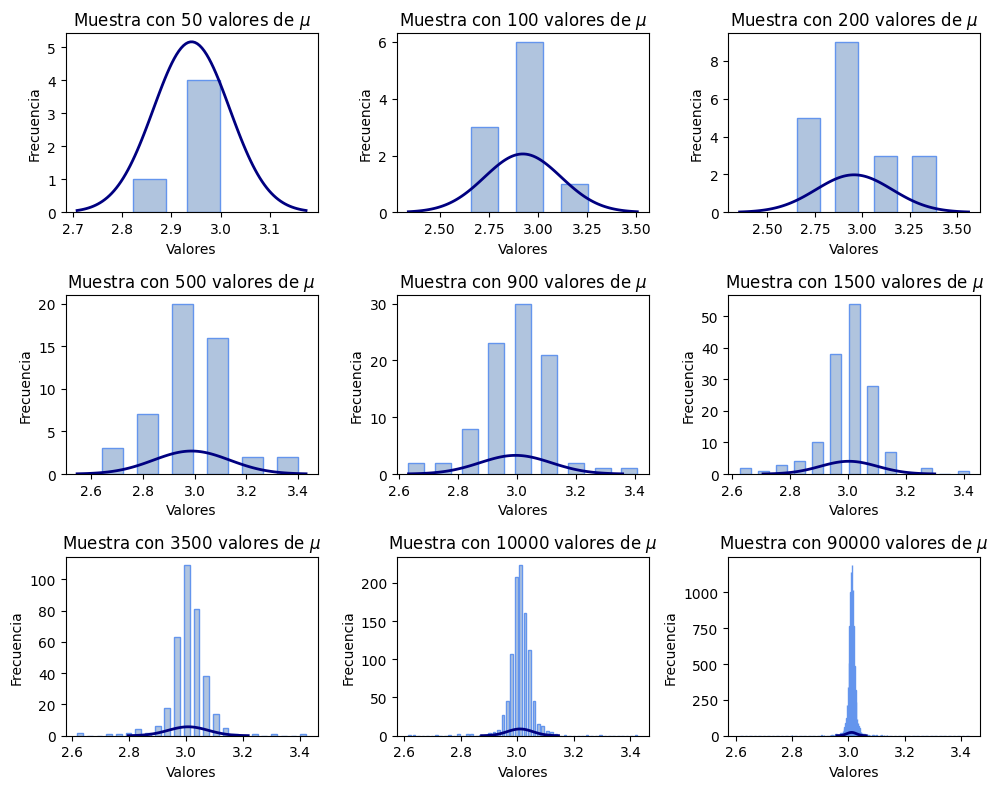

In [ ]:
import scipy.optimize as optimize

# Lista de valores para las muestras (ajusta estos valores según tus necesidades)
muestras_x = [5,10,20 , 50,  90, 150, 350,1000, 9000]

# Crear una figura con un subplot de 3x3
fig, axs = plt.subplots(3, 3, figsize=(10, 8))

# Itera sobre los subplots y grafica el histograma en cada uno
for i in range(3):
    for j in range(3):
        indice = i * 3 + j
        ax = axs[i, j]
        if indice < len(muestras_x):
            ax.hist(mean_[:muestras_x[indice]],edgecolor='cornflowerblue',color="lightsteelblue", rwidth=0.6, bins='scott')
            ax.set_xlabel('Valores')
            ax.set_ylabel('Frecuencia')
            ax.set_title(r'Muestra con {} valores de $\mu$'.format(n[muestras_x[indice]]))

        # Ajustar una distribución normal a los datos
            mu = np.mean(mean_[:muestras_x[indice]])
            sigma = np.std(mean_[:muestras_x[indice]])
            x = np.linspace(mu - 3 * sigma, mu + 3 * sigma, 100)
            ax.plot(x, stats.norm.pdf(x, mu, sigma), color='navy', lw=2, label='Distribución normal')

        else:
            ax.axis('off')  # Apagar subplots adicionales si no hay suficientes muestras

# Ajustar el espaciado entre subplots
plt.tight_layout()
plt.savefig('muest.png')


